# Human activity recognition
UCI HAR dataset

In [210]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset

## Data import and analysis

### Import train data

In [179]:
with open('UCI HAR Dataset/features.txt', encoding='utf-8') as f:
    features = [line.split() for line in f.readlines()]
print(len(features))

561


In [180]:
features[:10]

[['1', 'tBodyAcc-mean()-X'],
 ['2', 'tBodyAcc-mean()-Y'],
 ['3', 'tBodyAcc-mean()-Z'],
 ['4', 'tBodyAcc-std()-X'],
 ['5', 'tBodyAcc-std()-Y'],
 ['6', 'tBodyAcc-std()-Z'],
 ['7', 'tBodyAcc-mad()-X'],
 ['8', 'tBodyAcc-mad()-Y'],
 ['9', 'tBodyAcc-mad()-Z'],
 ['10', 'tBodyAcc-max()-X']]

In [181]:
seen = set()
uniq_features = []
for idx, name in features:
    new_name = name
    i = 1
    while new_name in seen:
        new_name = f"{name}_duplicate{i}"
        i += 1
    seen.add(new_name)
    uniq_features.append([idx, new_name])
len(uniq_features)

561

In [182]:
features_names = [feature[1] for feature in uniq_features]
X_train = pd.read_csv('UCI HAR Dataset/train/X_train.txt', sep='\s+', header=None, names=features_names)
X_train['subject'] = pd.read_csv('UCI HAR Dataset/train/subject_train.txt')
cols_to_drop = [col for col in X_train.columns if '_duplicate' in col]
print(f'Dropped duplicated columns {len(cols_to_drop)}')
X_train.drop(columns=cols_to_drop, inplace=True)
print(f'X_train shape: {X_train.shape}')
X_train.sample()

Dropped duplicated columns 84
X_train shape: (7352, 478)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject
4433,0.293945,-0.021808,-0.132951,-0.987669,-0.97544,-0.940169,-0.987038,-0.973169,-0.929584,-0.932463,...,-0.517401,-0.844257,-0.030033,-0.096572,-0.035358,0.28932,-0.667652,-0.020482,-0.187912,22.0


In [183]:
y_train = pd.read_csv('UCI HAR Dataset/train/y_train.txt', names=['Activity'])
activity_names_dict = {
    1: 'WALKING',
    2: 'WALKING_UPSTAIRS',
    3: 'WALKING_DOWNSTAIRS',
    4: 'SITTING',
    5: 'STANDING',
    6: 'LAYING'
}
y_train_labels = y_train['Activity'].map(activity_names_dict)
df_train = X_train
df_train['Activity'] = y_train['Activity']
df_train['Activity_name'] = y_train_labels

In [184]:
df_train.shape

(7352, 480)

In [185]:
df_train.sample()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity,Activity_name
2699,0.240316,0.022603,-0.069907,-0.050668,0.10281,-0.507998,-0.149254,0.077635,-0.480689,0.48972,...,0.359934,-0.651255,-0.95434,0.66391,-0.668862,0.324803,-0.013345,15.0,2,WALKING_UPSTAIRS


### Import test data

In [186]:
X_test = pd.read_csv('UCI HAR Dataset/test/X_test.txt', sep='\s+', header=None, names=features_names)
X_test['subject'] = pd.read_csv('UCI HAR Dataset/test/subject_test.txt')
X_test.drop(columns=cols_to_drop, inplace=True)
print(f'X_test shape: {X_test.shape}')
X_train.sample()

X_test shape: (2947, 478)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity,Activity_name
4860,0.345781,-0.024435,-0.120773,-0.335082,0.143579,0.0636,-0.407189,0.143749,0.087174,-0.101915,...,-0.934241,0.539943,0.536278,0.284848,-0.565224,0.241763,0.288903,23.0,2,WALKING_UPSTAIRS


In [187]:
y_test = pd.read_csv('UCI HAR Dataset/test/y_test.txt', names=['Activity'])
y_test_labels = y_test['Activity'].map(activity_names_dict)
df_test = X_test
df_test['Activity'] = y_test['Activity']
df_test['Activity_name'] = y_test_labels
df_test.shape

(2947, 480)

In [188]:
df_test.sample()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity,Activity_name
2797,0.282594,-0.018429,-0.114463,-0.996337,-0.987061,-0.979211,-0.996797,-0.985949,-0.980258,-0.936081,...,-0.047403,0.06518,0.04225,-0.037745,-0.577496,-0.124486,-0.176635,24.0,4,SITTING


### Analysis

In [189]:
print('No of duplicates in train: {}'.format(sum(df_train.duplicated())))
print('No of duplicates in test : {}'.format(sum(df_test.duplicated())))

No of duplicates in train: 0
No of duplicates in test : 0


In [190]:
print(f'{df_train.isnull().values.sum()} NaN/Null values in train')
print(f'{df_test.isnull().values.sum()} NaN/Null values in test')

1 NaN/Null values in train
1 NaN/Null values in test


In [191]:
df_train.dropna(inplace=True)
df_test.dropna(inplace=True)

In [192]:
df_test['subject']

0        2.0
1        2.0
2        2.0
3        2.0
4        2.0
        ... 
2941    24.0
2942    24.0
2943    24.0
2944    24.0
2945    24.0
Name: subject, Length: 2946, dtype: float64

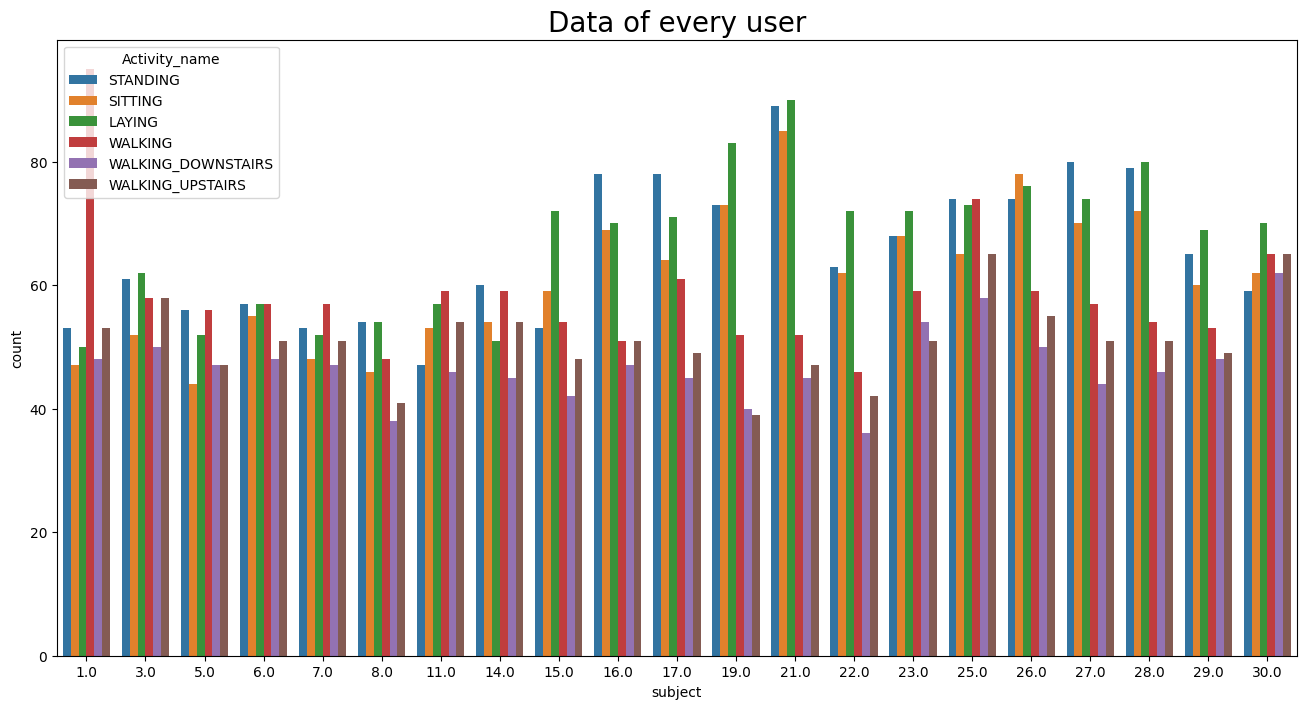

In [193]:
plt.figure(figsize=(16,8))
plt.title('Data of every user', fontsize=20)
sns.countplot(x='subject',hue='Activity_name', data = df_train)
plt.show()

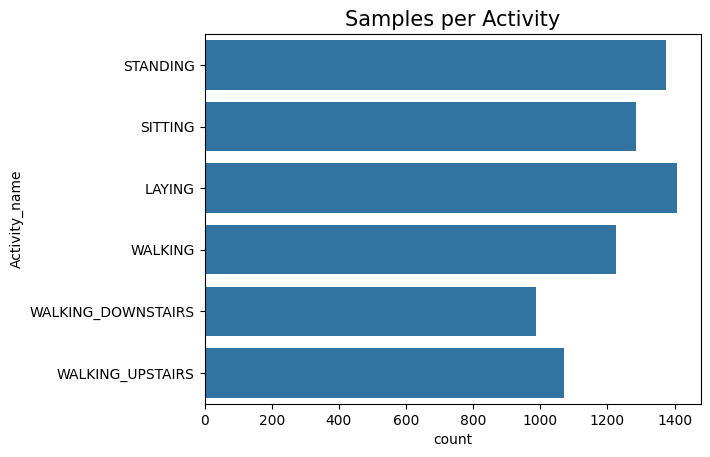

In [194]:
plt.title('Samples per Activity', fontsize=15)
sns.countplot(df_train['Activity_name'])
plt.show()

In [195]:
columns = df_train.columns
columns = columns.str.replace('[()]','')
columns = columns.str.replace('[-]', '')
columns = columns.str.replace('[,]','')

df_train.columns = columns
df_test.columns = columns

In [196]:
df_train.to_csv('train.csv', index=False)
df_test.to_csv('test.csv', index=False)

## Classifiers comparison

In [197]:
df_train = pd.read_csv('train.csv')
X_train = df_train.drop(['subject', 'Activity', 'Activity_name'], axis=1).to_numpy()
y_train = df_train['Activity'].to_numpy()
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2)

In [198]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape

((5880, 477), (5880,), (1471, 477), (1471,))

In [202]:
def print_result(model, X_train, X_val, y_train, y_val):
    y_pred = model.predict(X_train)
    print(f"Train f1 macro: {f1_score(y_train, y_pred, average='macro'):.2f}")
    y_pred = model.predict(X_val)
    print(f"Test f1 macro: {f1_score(y_val, y_pred, average='macro'):.2f}")
    sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Blues')

Train f1 macro: 0.05
Test f1 macro: 0.05


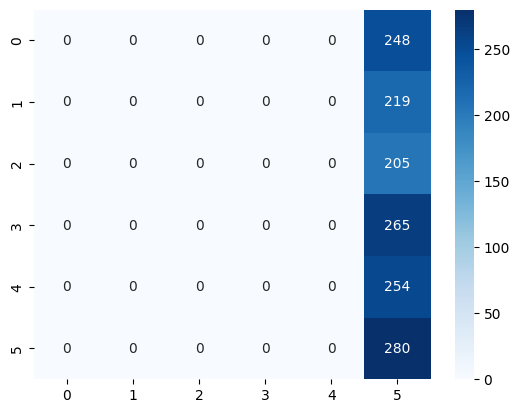

In [203]:
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train)
y_pred = dummy_clf.predict(X_train)
print_result(dummy_clf, X_train, X_val, y_train, y_val)

Train f1 macro: 0.98
Test f1 macro: 0.96


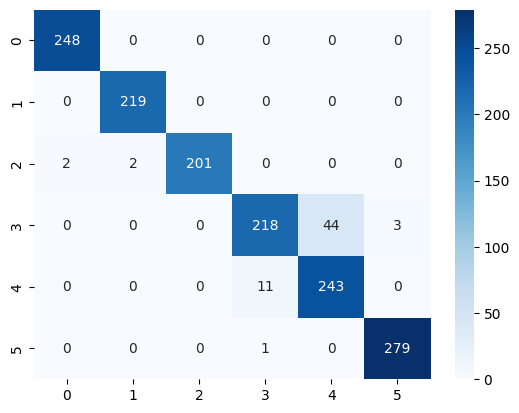

In [204]:
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_train)
print_result(knn_clf, X_train, X_val, y_train, y_val)

Train f1 macro: 0.98
Test f1 macro: 0.98


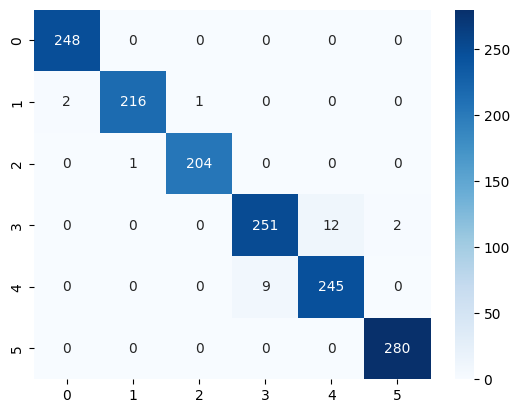

In [205]:
svm_clf = SVC()
svm_clf.fit(X_train, y_train)
print_result(svm_clf, X_train, X_val, y_train, y_val)

Train f1 macro: 0.99
Test f1 macro: 0.99


d:\python_envs\datascience_env\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


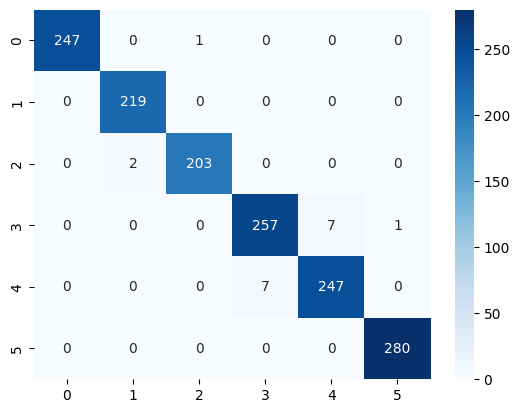

In [206]:
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
print_result(lr_clf, X_train, X_val, y_train, y_val)

Train f1 macro: 1.00
Test f1 macro: 0.99


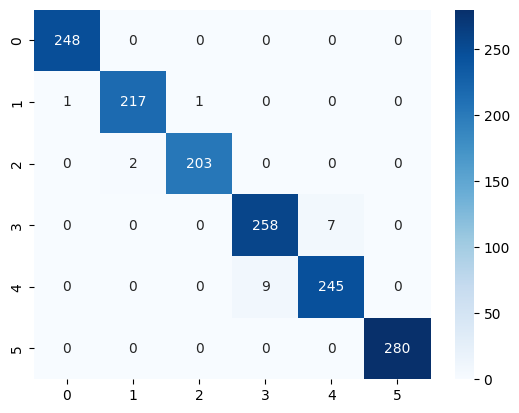

In [207]:
rf_clf = RandomForestClassifier()
rf_clf.fit(X_train, y_train)
print_result(rf_clf, X_train, X_val, y_train, y_val)

Train f1 macro: 1.00
Test f1 macro: 0.99


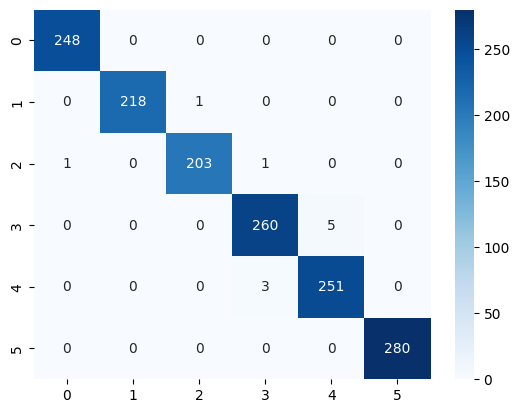

In [208]:
gb_clf = GradientBoostingClassifier()
gb_clf.fit(X_train, y_train)
print_result(gb_clf, X_train, X_val, y_train, y_val)

### Classifiers results
| Model | Train f1 | Val f1 | 
|-|-|-|
| Random forest | 1 | 0.99 | 
| Gradient boosting| 1 | 0.99 | 
| Log reg | 0.99 | 0.99 |  
| SVM | 0.98 | 0.98 | 
| K-nn | 0.98 | 0.96 | 
| Dummy | 0.05 | 0.05  |  

## Test result

In [214]:
df_test = pd.read_csv('test.csv')
X_test = df_test.drop(['subject', 'Activity', 'Activity_name'], axis=1).to_numpy()
y_test = df_test['Activity'].to_numpy()

Train f1 macro: 1.00
Test f1 macro: 0.92


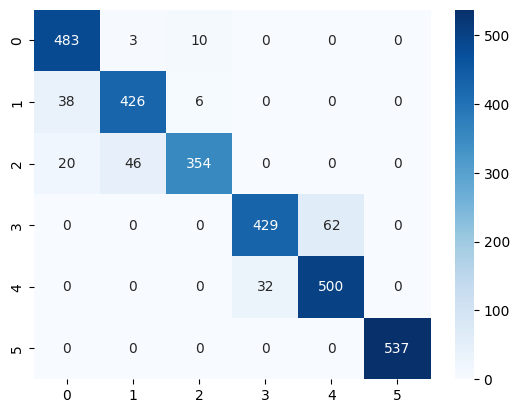

In [215]:
rf_clf = RandomForestClassifier()
rf_clf.fit(X_train, y_train)
print_result(rf_clf, X_train, X_test, y_train, y_test)